# Web Scraping de Lectulandia.

In [1]:
# Si no tienen las librerias, descomentenlas.

# Instalar dependencias en Colab
!uv pip install --system playwright
!playwright install
!playwright install-deps
# Install missing system dependencies for Playwright
!apt-get update && apt-get install -y libatk1.0-0 libatk-bridge2.0-0 libgtk-3-0 libgdk-pixbuf2.0-0 libnss3 libxss1 libasound

Using Python 3.13.15 environment at: /usr
Resolved 4 packages in 390ms
Prepared 2 packages in 1.42s
Installed 2 packages in 16ms
 + playwright==1.62.0
 + pyee==13.0.1
184.3 MiB [] 0% 0.0s184.3 MiB [] 0% 67.6s184.3 MiB [] 0% 61.7s184.3 MiB [] 0% 42.9s184.3 MiB [] 0% 31.7s184.3 MiB [] 0% 27.2s184.3 MiB [] 0% 21.3s184.3 MiB [] 0% 14.4s184.3 MiB [] 1% 13.4s184.3 MiB [] 1% 10.9s184.3 MiB [] 1% 8.9s184.3 MiB [] 2% 8.1s184.3 MiB [] 2% 7.6s184.3 MiB [] 3% 7.0s184.3 MiB [] 3% 6.8s184.3 MiB [] 3% 6.6s184.3 MiB [] 4% 6.6s184.3 MiB [] 4% 6.5s184.3 MiB [] 4% 6.4s184.3 MiB [] 5% 6.1s184.3 MiB [] 5% 5.7s184.3 MiB [] 6% 5.2s184.3 MiB [] 7% 5.2s184.3 MiB [] 7% 5.3s184.3 MiB [] 7% 5.4s184.3 MiB [] 7% 5.5s184.3 MiB [] 8% 5.3s184.3 MiB [] 9% 4.8s184.3 MiB [] 10% 4.4s184.3 MiB [] 11% 4.0s184.3 MiB [] 11% 3.9s184.3 MiB [] 13% 3.7s184.3 MiB [] 13% 3.6s184.3 MiB [] 14% 3.5s184.3 MiB [] 15% 3.3s184.3 MiB [] 16% 3.2s184.3 MiB [] 16% 3.1s184.3 MiB [] 17% 3.0s184.3 MiB [] 18% 3.0s184.3 MiB [] 18% 2.9s184.3 MiB []

In [2]:
# librerias a utilizar
import asyncio
import os
import random
from datetime import datetime
from bs4 import BeautifulSoup
import pandas as pd
from playwright.async_api import async_playwright

In [4]:
url = "https://ww3.lectulandia.co/genero/aventuras/"

Nombre de la categoría. Aventuras \
URL de la categoría. https://ww3.lectulandia.com/genero/aventuras/ \
Cantidad de libros que se propone extraer. 200\
Criterio utilizado para seleccionar las páginas. Todos los que estan


| Campo |  Descripción |
|-------|--------------|
| titulo | Título del libro |
| autores | Autor o autores o NaN |
| generos | Género o géneros o NaN |
| serie | Serie a la que pertenece, si corresponde |
| sinopsis |Texto completo de la sinopsis |
| url_libro | Dirección de la ficha |
| categoria_origen | Categoría seleccionada por el grupo |
| fecha_extraccion | Fecha en que se obtuvo el registro |



**LOCALIZACION DE LOS DATOS (Analizando codigo fuente del html y sus etiquetas)**

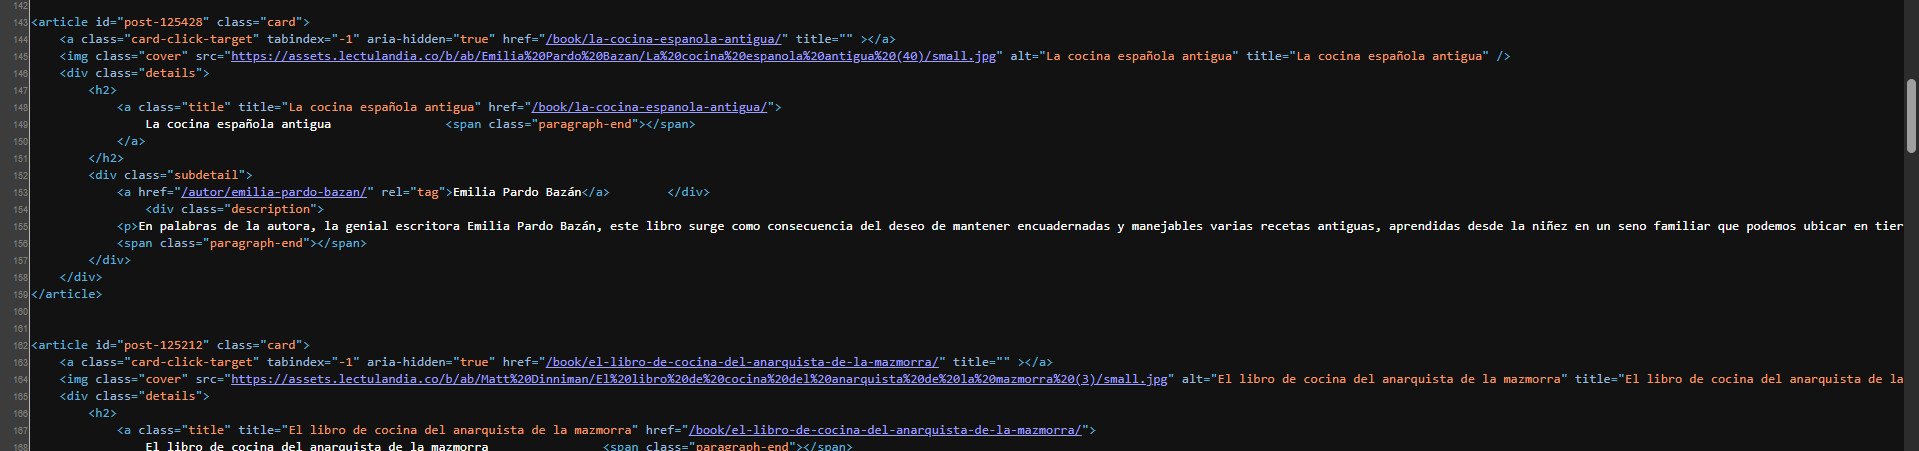

|Dato |  Tipo de pagina | Etiqueta HTML | Selector propuesto | Extraccion |
|-------|----------------|----------------|----------------|----------------|
|titulo|Ficha individual| < h2 > / < h1 > |div.details h2 a.title (o h1#title)|soup.select_one("a.title").get_text(strip=True)
|autores|Ficha individual|< a >|div.subdetail a[href*='/autor/']|", ".join([a.get_text(strip=True) for a in soup.select("a[href*='/autor/']")])|
|generos|Ficha individual|< a >|a[href*='/genero/']|", ".join([g.get_text(strip=True) for g in soup.select("a[href*='/genero/']")])|
|serie|Ficha individual|< a >|div.subdetail a[href*='/serie/']|soup.select_one("a[href*='/serie/']").get_text(strip=True) (o None si no existe)|
|sinopsis|Ficha individual|< div > / < p >|div.description (o div#sinopsis)|soup.select_one("div.description").get_text(separator=" ", strip=True)|
|url_libro|Ficha individual|-|Propiedad del loop|URL absoluta ([https://ww3.lectulandia.co](https://ww3.lectulandia.co) + href)|
|categoria_origen|Ficha individual|-|Constante|"Aventuras"|
|fecha_extraccion| Ficha individual|-|Función Python|datetime.now().strftime("%Y-%m-%d %H:%M:%S")|

**SELECTORES DE LA LISTA DE BUSQUEDA**

Para la extracción de URLs desde los resultados de búsqueda (/genero/aventuras/):

  1) **Lista de libros / Fichas:** article.card o div.archive-content a.title

  2) **Enlace a la ficha:** a.cover o a.title (extraer el atributo href).

**ESTRATEGIA DE EXTRACCION**

1) **Inicio:** Iniciar Playwright en modo headless (sin abrir ventana visual) configurando un User-Agent común.

2) **Carga y Paginación:** Navegar a [https://ww3.lectulandia.co/genero/aventuras/](https://ww3.lectulandia.co/genero/aventuras/).

3) **Parseo con BeautifulSoup:** Extraer el HTML de los resultados y obtener los enlaces href de cada ficha.

4) **Navegación a Fichas:** Visitar cada ficha individualmente con Playwright.

5) **Extracción:** Pasar el HTML obtenido a BeautifulSoup para extraer título, autor, género, serie, sinopsis y portada mediante los selectores detallados.

6) **Robustez y Pausas:** Incluir bloques try/except por cada ficha para evitar el colapso del script si una página falla, además de pausas aleatorias de 1 a 3 segundos entre peticiones para simular comportamiento humano.

7) **Guardado Incremental:** Escribir los registros en el archivo libros.csv cada 10 libros procesados.

8) **Deduplicación y Calidad:** Al finalizar, cargar el CSV final en Pandas para verificar que no existan duplicados por url_libro, limpiar espacios en blanco sobrantes y aplicar los controles requeridos.

In [5]:
# Configuración del Scraping
BASE_URL = "https://ww3.lectulandia.co"
URL_INICIAL = "https://ww3.lectulandia.com/genero/aventuras/"
CATEGORIA_NOMBRE = "Aventuras"
OBJETIVO_LIBROS = 200  # Entre 100 y 200 libros
TOTAL_PAGINAS_DISPONIBLES = 17
ARCHIVO_CSV = "libros.csv"

async def extraer_datos_ficha(context, url_libro):
    """Visita la ficha individual creando una pestaña nueva para evitar contaminación de datos."""

    # 1. AISLAMIENTO: Abrimos una nueva pestaña limpia para ESTE libro específico
    page = await context.new_page()

    try:
        await page.goto(url_libro, wait_until="domcontentloaded", timeout=30000)
        await page.wait_for_timeout(random.randint(1500, 3000))

        # 2. VERIFICACIÓN ANTI-BOTS: Comprobar si nos redirigieron a otro lado
        url_actual = page.url
        # Comparamos las URLs ignorando si a una le falta la barra final '/'
        if url_actual.rstrip('/') != url_libro.rstrip('/'):
            print(f"\n[!] REDIRECCIÓN DETECTADA (Posible bloqueo Anti-Bot).")
            print(f"    Queríamos ir a : {url_libro}")
            print(f"    Terminamos en  : {url_actual}")
            return None # Saltamos este libro porque los datos serán de otra página

        html = await page.content()
        soup = BeautifulSoup(html, "html.parser")

        # 3. CONTENEDOR ESTRICTO: Buscar la etiqueta que envuelve el contenido principal.
        # Esto evita que BeautifulSoup lea la barra lateral (sidebar) o pie de página.
        main_container = soup.select_one("div#main") or soup.select_one("div#content") or soup.select_one("main") or soup

        # Extraemos usando solo el main_container
        titulo_elem = main_container.select_one("h1#title") or main_container.select_one("h1")
        titulo = titulo_elem.get_text(strip=True) if titulo_elem else None

        if not titulo:
            return None

        # Autores y Géneros dentro del contenedor principal
        autores_elems = main_container.select("a[href*='/autor/']")
        autores_list = list(dict.fromkeys([a.get_text(strip=True) for a in autores_elems if a.get_text(strip=True)]))
        autores = ", ".join(autores_list) if autores_list else None

        generos_elems = main_container.select("a[href*='/genero/']")
        generos_list = list(dict.fromkeys([g.get_text(strip=True) for g in generos_elems if g.get_text(strip=True)]))
        generos = ", ".join(generos_list) if generos_list else None

        serie_elem = main_container.select_one("a[href*='/serie/']")
        serie = serie_elem.get_text(strip=True) if serie_elem else None

        # Sinopsis y portada
        sinopsis_elem = main_container.select_one("div#sinopsis") or main_container.select_one("div.description") or main_container.select_one("div.entry-content")
        sinopsis = sinopsis_elem.get_text(separator=" ", strip=True) if sinopsis_elem else None

        return {
            "titulo": titulo,
            "autores": autores,
            "generos": generos,
            "serie": serie,
            "sinopsis": sinopsis,
            "url_libro": url_libro, # Guardamos la URL original que pedimos
            "categoria_origen": CATEGORIA_NOMBRE,
            "fecha_extraccion": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        }

    except Exception as e:
        print(f"[ERROR] No se pudo procesar la ficha {url_libro}: {e}")
        return None

    finally:
        # 4. LIMPIEZA: Siempre cerramos la pestaña al terminar, haya éxito o error
        await page.close()

async def main():
    urls_procesadas = set()

    # Control de duplicados si existe un CSV previo
    if os.path.exists(ARCHIVO_CSV):
        try:
            df_previo = pd.read_csv(ARCHIVO_CSV)
            if "url_libro" in df_previo['url_libro']:
                urls_procesadas = set(df_previo["url_libro"].dropna().tolist())
                print(f"Cargadas {len(urls_procesadas)} URLs previamente procesadas.")
        except Exception as e:
            print(f"No se pudo leer el archivo previo: {e}")

    async with async_playwright() as p:
        # Iniciar navegador Chromium en modo Headless (sin GUI)
        browser = await p.chromium.launch(headless=True)
        context = await browser.new_context(
            user_agent="Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
        )
        page = await context.new_page()

        urls_libros = []

        print("--- PASO 1: Recolectando URLs desde las páginas de búsqueda ---")
        for pagina_num in range(1, TOTAL_PAGINAS_DISPONIBLES + 1):
            if len(urls_libros) >= OBJETIVO_LIBROS:
                break

            url_pagina = f"{URL_INICIAL}/page/{pagina_num}/" if pagina_num > 1 else URL_INICIAL
            print(f"Explorando búsqueda página {pagina_num}/{TOTAL_PAGINAS_DISPONIBLES}: {url_pagina}")

            try:
                response = await page.goto(url_pagina, wait_until="domcontentloaded", timeout=30000)
                if response and response.status == 404:
                    print("Página no encontrada (404). Fin del recorrido.")
                    break

                html = await page.content()
                soup = BeautifulSoup(html, "html.parser")

                # Selector verificado del HTML real: <article class="card"> -> <a class="title">
                articles = soup.select("article.card")
                nuevos_links = []

                for art in articles:
                    link_tag = art.select_one("a.title") or art.select_one("a.card-click-target")
                    if link_tag and link_tag.get("href"):
                        href = link_tag.get("href")
                        # Asegurar URL absoluta
                        full_url = href if href.startswith("http") else f"{BASE_URL}{href}"

                        if full_url not in urls_procesadas and full_url not in urls_libros:
                            nuevos_links.append(full_url)

                if not nuevos_links:
                    print(f"No se encontraron enlaces nuevos en la página {pagina_num}.")

                urls_libros.extend(nuevos_links)
                print(f"-> Agregados {len(nuevos_links)} libros. Total acumulado: {len(urls_libros)}")

                # Pausa antes de ir a la siguiente página de búsqueda
                await page.wait_for_timeout(random.randint(1500, 3000))

            except Exception as e:
                print(f"Error procesando la página {pagina_num}: {e}")
                continue

        # Limitar al objetivo propuesto
        urls_libros = urls_libros[:OBJETIVO_LIBROS]
        print(f"\n--- PASO 2: Visitando {len(urls_libros)} fichas individuales ---")

        buffer_registros = []
        for i, url in enumerate(urls_libros, start=1):
            print(f"[{i}/{len(urls_libros)}] Extrayendo: {url}")
            datos = await extraer_datos_ficha(context, url)

            if datos:
                buffer_registros.append(datos)

            # Guardado incremental en CSV cada 10 registros procesados
            if len(buffer_registros) >= 10 or i == len(urls_libros):
                if buffer_registros:
                    df_chunk = pd.DataFrame(buffer_registros)
                    # Limpieza general de espacios en blanco
                    df_chunk = df_chunk.map(lambda x: x.strip() if isinstance(x, str) else x)

                    header_flag = not os.path.exists(ARCHIVO_CSV)
                    df_chunk.to_csv(ARCHIVO_CSV, mode="a", index=False, header=header_flag, encoding="utf-8-sig")
                    print(f"  [+] Guardado incremental: {len(buffer_registros)} filas agregadas a {ARCHIVO_CSV}")
                    buffer_registros = []

        await browser.close()

    print("\n--- PASO 3: Validación y Controles Mínimos ---")
    if os.path.exists(ARCHIVO_CSV):
        df_final = pd.read_csv(ARCHIVO_CSV)

        # Eliminación de registros duplicados por url_libro
        df_final.drop_duplicates(subset=["url_libro"], keep="first", inplace=True)
        df_final.to_csv(ARCHIVO_CSV, index=False, encoding="utf-8-sig")

        # Impresión de controles mínimos requeridos
        print("====== REPORTE DE CONTROLES MÍNIMOS ======")
        print(f"1. Total de registros finales: {len(df_final)} (Requerido: entre 100 y 200)")
        print(f"2. Registros con título válido: {df_final['titulo'].notna().sum()} / {len(df_final)}")
        print(f"3. Registros con URL válida: {df_final['url_libro'].notna().sum()} / {len(df_final)}")
        print(f"4. Cobertura de Sinopsis: {(df_final['sinopsis'].notna().mean() * 100):.1f}%")
        print(f"5. Duplicados por url_libro: {df_final['url_libro'].duplicated().sum()}")

await main()

--- PASO 1: Recolectando URLs desde las páginas de búsqueda ---
Explorando búsqueda página 1/17: https://ww3.lectulandia.com/genero/aventuras/
-> Agregados 24 libros. Total acumulado: 24
Explorando búsqueda página 2/17: https://ww3.lectulandia.com/genero/aventuras//page/2/
-> Agregados 24 libros. Total acumulado: 48
Explorando búsqueda página 3/17: https://ww3.lectulandia.com/genero/aventuras//page/3/
-> Agregados 24 libros. Total acumulado: 72
Explorando búsqueda página 4/17: https://ww3.lectulandia.com/genero/aventuras//page/4/
-> Agregados 24 libros. Total acumulado: 96
Explorando búsqueda página 5/17: https://ww3.lectulandia.com/genero/aventuras//page/5/
-> Agregados 24 libros. Total acumulado: 120
Explorando búsqueda página 6/17: https://ww3.lectulandia.com/genero/aventuras//page/6/
-> Agregados 24 libros. Total acumulado: 144
Explorando búsqueda página 7/17: https://ww3.lectulandia.com/genero/aventuras//page/7/
-> Agregados 24 libros. Total acumulado: 168
Explorando búsqueda pági

In [6]:
df_libros = pd.read_csv('libros.csv')

In [7]:
df_libros

,titulo,autores,generos,serie,sinopsis,url_libro,categoria_origen,fecha_extraccion
0,Persiguiendo a Bécquer,"Miguel Lago, Teo Palacios, Karl von Vereiter, ...","Genero: Aventuras, Aventuras, Humor, Novela, P...",Bécquer - 1,"Antoñito, el nieto de don Manuel, creció con s...",https://ww3.lectulandia.co/book/persiguiendo-a...,Aventuras,2026-09-03 22:27:21
1,La canción de Hands,"Miguel Lago, Teo Palacios, Karl von Vereiter, ...","Genero: Aventuras, Aventuras, Histórico, Intri...",Bécquer - 1,"Armando Villalobos, un restaurador de muebles ...",https://ww3.lectulandia.co/book/la-cancion-de-...,Aventuras,2026-09-03 22:27:23
2,Batallón disciplinario,"Miguel Lago, Teo Palacios, Karl von Vereiter, ...","Genero: Aventuras, Aventuras, Bélico, Novela",Bécquer - 1,De todas las unidades especiales que la Wehrma...,https://ww3.lectulandia.co/book/batallon-disci...,Aventuras,2026-09-03 22:27:25
3,King,"Miguel Lago, Teo Palacios, Karl von Vereiter, ...","Genero: Aventuras, Aventuras, Erótico, Novela,...",Bécquer - 1,El mundo del crimen y la mafia de Nueva York t...,https://ww3.lectulandia.co/book/king/,Aventuras,2026-09-03 22:27:29
4,El guardián de los dioses,"Miguel Lago, Teo Palacios, Karl von Vereiter, ...","Genero: Aventuras, Aventuras, Histórico, Intri...",Bécquer - 1,El final de la orden del temple es solo el pri...,https://ww3.lectulandia.co/book/el-guardian-de...,Aventuras,2026-09-03 22:27:32
...,...,...,...,...,...,...,...,...
195,Momo (ed. original),"Miguel Lago, Teo Palacios, Karl von Vereiter, ...","Genero: Aventuras, Aventuras, Fantástico, Juve...",Bécquer - 1,"Momo es una niña muy especial, posee la maravi...",https://ww3.lectulandia.co/book/momo-ed-original/,Aventuras,2026-09-03 22:36:38
196,Pentamerón,"Miguel Lago, Teo Palacios, Karl von Vereiter, ...","Genero: Aventuras, Aventuras, Fantástico, Juve...",Bécquer - 1,Pocos lectores saben que algunas de las más he...,https://ww3.lectulandia.co/book/pentameron/,Aventuras,2026-09-03 22:36:40
197,Allan en Egipto o El antiguo Allan,"Miguel Lago, Teo Palacios, Karl von Vereiter, ...","Genero: Aventuras, Aventuras, Ciencia ficción,...",Bécquer - 1,Con la proverbial maestría que todos reconocen...,https://ww3.lectulandia.co/book/allan-en-egipt...,Aventuras,2026-09-03 22:36:43
198,La historia de Gillion de Trazegnies,"Miguel Lago, Teo Palacios, Karl von Vereiter, ...","Genero: Aventuras, Aventuras, Relato",Bécquer - 1,"Gillion no puede tener hijos de Marie, su espo...",https://ww3.lectulandia.co/book/la-historia-de...,Aventuras,2026-09-03 22:36:45
